# Supermarket Sales & Customer Analysis 

## Overview 

This notebook analyzes 1,000 SuperMarket transactions spanning January 1 - March 30,2019, across three branches (Alex, Cairo, Giza). The objective is to answer eight business questions covering revenue performance, product line trends, customer spending behavior, and payment preferences. 

**Dataset:** `SuperMarket Analysis.csv` - 1,000 rows * 17 columns

Importing Libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

Loading The Dataset

In [2]:
sales_data=pd.read_csv("SuperMarket Analysis.csv")

Inspecting The Data 

In [3]:
sales_data.shape

(1000, 17)

In [4]:
sales_data.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [5]:
sales_data.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,Alex,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,1:28:00 PM,Cash,618.38,4.761905,30.9190,6.6


In [6]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [7]:
sales_data.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [8]:
sales_data.dtypes

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [9]:
sales_data.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


Data Cleaning and Validation

In [10]:
sales_data.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [11]:
sales_data.duplicated().sum()

np.int64(0)

In [12]:
sales_data.sample(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
193,641-43-2399,Cairo,Mandalay,Normal,Male,Home and lifestyle,25.55,4,5.110,107.310,1/26/2019,8:23:00 PM,Ewallet,102.20,4.761905,5.110,5.7
149,238-49-0436,Alex,Yangon,Normal,Male,Health and beauty,32.46,8,12.984,272.664,3/27/2019,1:48:00 PM,Credit card,259.68,4.761905,12.984,4.9
555,356-44-8813,Cairo,Mandalay,Normal,Male,Home and lifestyle,37.48,3,5.622,118.062,1/20/2019,1:45:00 PM,Credit card,112.44,4.761905,5.622,7.7
593,880-35-0356,Alex,Yangon,Member,Female,Sports and travel,75.20,3,11.280,236.880,2/5/2019,11:51:00 AM,Ewallet,225.60,4.761905,11.280,4.8
145,458-41-1477,Giza,Naypyitaw,Normal,Female,Health and beauty,46.26,6,13.878,291.438,3/8/2019,5:11:00 PM,Credit card,277.56,4.761905,13.878,9.5


In [13]:
for col in ["Branch","City","Customer type","Gender","Product line","Payment"]:
    print(f"\n{col}:")
    print(sales_data[col].unique())


Branch:
['Alex' 'Giza' 'Cairo']

City:
['Yangon' 'Naypyitaw' 'Mandalay']

Customer type:
['Member' 'Normal']

Gender:
['Female' 'Male']

Product line:
['Health and beauty' 'Electronic accessories' 'Home and lifestyle'
 'Sports and travel' 'Food and beverages' 'Fashion accessories']

Payment:
['Ewallet' 'Cash' 'Credit card']


In [14]:
sales_data["Date"]=pd.to_datetime(sales_data["Date"])

In [15]:
sales_data["Date"].min(),sales_data["Date"].max()

(Timestamp('2019-01-01 00:00:00'), Timestamp('2019-03-30 00:00:00'))

In [16]:
sales_data["Date"].dtype

dtype('<M8[ns]')

In [17]:
sales_data["Time"].head()

0     1:08:00 PM
1    10:29:00 AM
2     1:23:00 PM
3     8:33:00 PM
4    10:37:00 AM
Name: Time, dtype: object

In [18]:
sales_data[["Unit price","Quantity","Sales","cogs","gross income"]].min()

Unit price      10.0800
Quantity         1.0000
Sales           10.6785
cogs            10.1700
gross income     0.5085
dtype: float64

In [19]:
sales_data["Invoice ID"].duplicated().sum()

np.int64(0)

In [20]:
np.isclose(sales_data["Sales"]-sales_data["cogs"],sales_data["gross income"]).all()

np.True_

In [21]:
difference=sales_data["Sales"]-sales_data["cogs"]-sales_data["gross income"]

difference

0     -4.973799e-14
1     -6.661338e-15
2      2.131628e-14
3      1.065814e-14
4      7.105427e-14
           ...     
995   -1.776357e-15
996    5.684342e-14
997    2.220446e-15
998    1.110223e-14
999   -1.776357e-14
Length: 1000, dtype: float64

In [22]:
sales_data["Rating"].min(), sales_data["Rating"].max()

(np.float64(4.0), np.float64(10.0))

In [23]:
sales_data["Month"]=sales_data["Date"].dt.month_name()

In [24]:
sales_data["Month"].value_counts()

Month
January     352
March       345
February    303
Name: count, dtype: int64

### Q.1. What is the total revenue generated during the analysis period?

In [25]:
# How Much Revenue did The Supermarket Generate during the entire period ? 

total_revenue =sales_data["Sales"].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 322,966.75


### Q.2. Which branch generates the highest revenue?

In [26]:
# Which Branch generated the most revenue ? 

sales_data.groupby("Branch")["Sales"].sum().sort_values(ascending=False)

Branch
Giza     110568.7065
Alex     106200.3705
Cairo    106197.6720
Name: Sales, dtype: float64

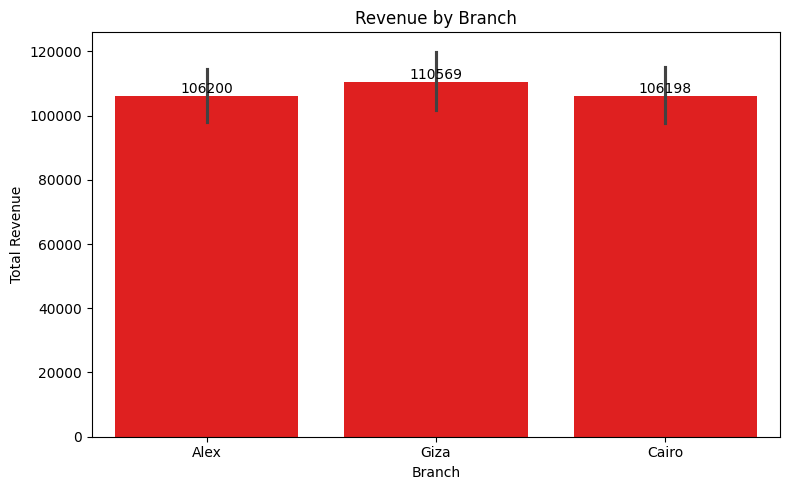

In [27]:
plt.figure(figsize=(8,5))

ax=sns.barplot(
    data=sales_data,
    x="Branch",
    y="Sales",
    estimator=sum,
    color="Red"
)

plt.title("Revenue by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Revenue")

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")
    
plt.tight_layout()
plt.show()

### Q.3. How does revenue change over time?

In [28]:
# How did Revenue Change Over Time ? 

sales_data.groupby("Month")["Sales"].sum()

Month
February     97219.374
January     116291.868
March       109455.507
Name: Sales, dtype: float64

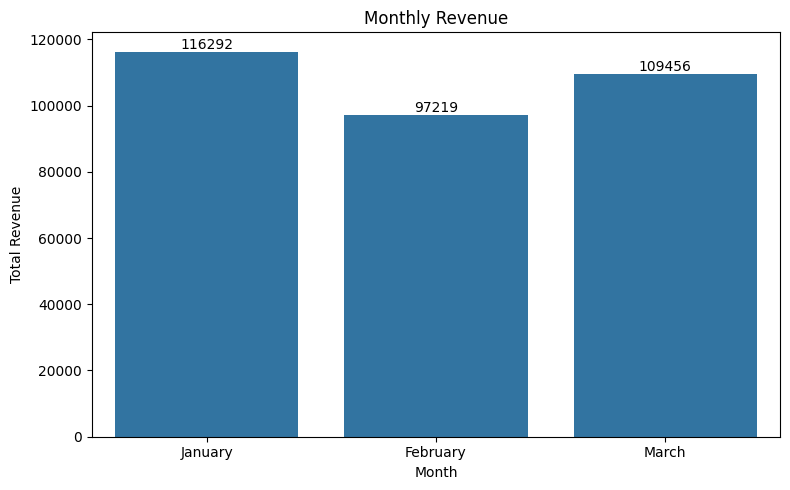

In [29]:
monthly_sales=sales_data.groupby("Month")["Sales"].sum().reindex(
    ["January","February","March"]
)

plt.figure(figsize=(8,5))

ax=sns.barplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    
    
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")
    
plt.tight_layout()
plt.show()

### Q.4. Which Product line generates the most revenue?

In [30]:
# Which Product line generates the most Revenue ? 

sales_data.groupby("Product line")["Sales"].sum().sort_values(ascending=False)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Sales, dtype: float64

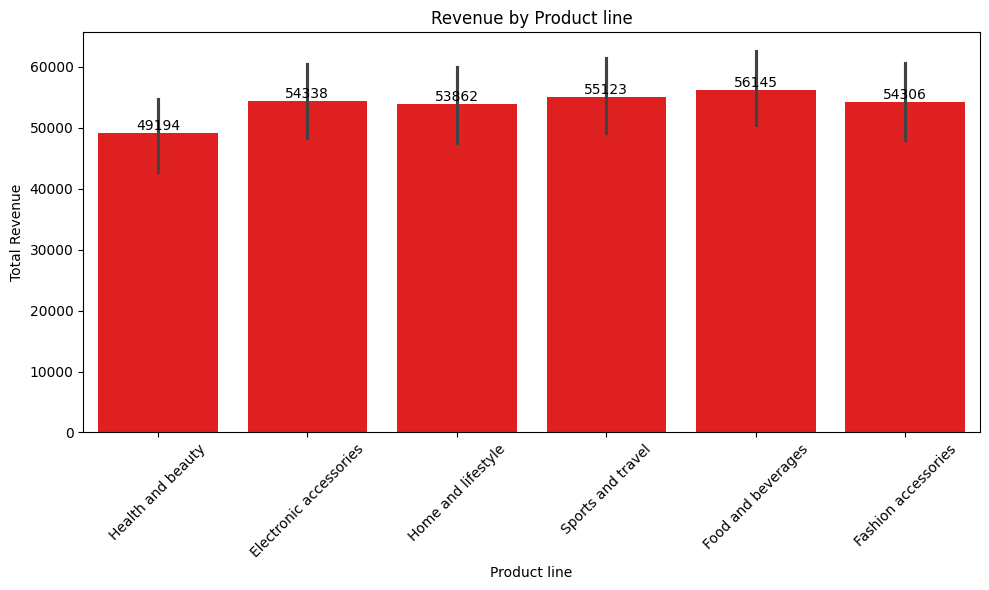

In [31]:
plt.figure(figsize=(10,6))

ax=sns.barplot(
    data=sales_data,
    x="Product line",
    y="Sales",
    estimator=sum,
    color="red"
)

plt.xticks(rotation=45)
plt.title("Revenue by Product line")
plt.xlabel("Product line")
plt.ylabel("Total Revenue")

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")
    
plt.tight_layout()
plt.show()

### Q.5. Which product lines sell the most units?

In [32]:
# Which Product line sells the most Unit ? 

sales_data.groupby("Product line")["Quantity"].sum().sort_values(ascending=False)

Product line
Electronic accessories    971
Food and beverages        952
Sports and travel         920
Home and lifestyle        911
Fashion accessories       902
Health and beauty         854
Name: Quantity, dtype: int64

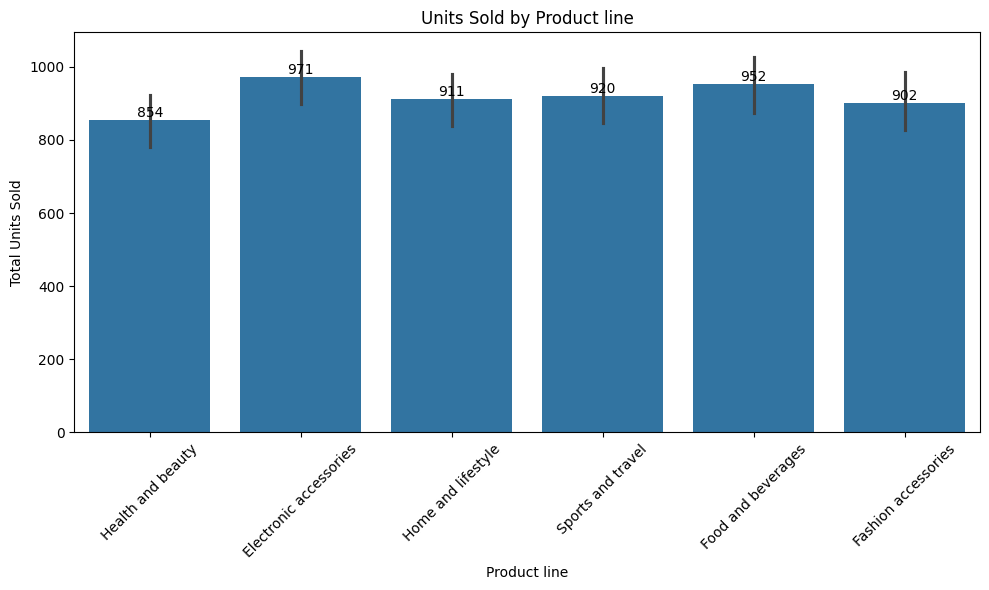

In [33]:
plt.figure(figsize=(10,6))

ax=sns.barplot(
    data=sales_data,
    x="Product line",
    y="Quantity",
    estimator=sum
)
plt.xticks(rotation=45)
plt.title("Units Sold by Product line")
plt.xlabel("Product line")
plt.ylabel("Total Units Sold")

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")
    
plt.tight_layout()
plt.show()

In [34]:
# Why do the revenue and unit leaders differ? 

product_revenue = sales_data.groupby("Product line")["Sales"].sum()

product_revenue_pct = (product_revenue / sales_data["Sales"].sum())*100

product_revenue_pct.sort_values(ascending=False)

Product line
Food and beverages        17.384094
Sports and travel         17.067648
Electronic accessories    16.824497
Fashion accessories       16.814702
Home and lifestyle        16.677232
Health and beauty         15.231828
Name: Sales, dtype: float64

In [35]:
sales_data.groupby("Product line")["Unit price"].mean().loc[
    ["Electronic accessories","Food and beverages"]
]

Product line
Electronic accessories    53.551588
Food and beverages        56.008851
Name: Unit price, dtype: float64

Insight : Food and Beverages leads on revenue despite selling fewer units than Electronic accessories, because its average unit price (56.01) exceeds Electronic accessories' (53.55). This suggests pricing power in Food and beverages and volume-driven sales in Electronic accessories. 

### Q.6. How does average spending differ between customer types?

In [36]:
# Do Member and Normal customers differ in their spending ? 

sales_data.groupby("Customer type")["Sales"].sum()

Customer type
Member    189694.764
Normal    133271.985
Name: Sales, dtype: float64

In [37]:
# On Average , how much does a member vs. Normal Customer spend per transaction ? 

sales_data.groupby("Customer type")["Sales"].mean()

Customer type
Member    335.742945
Normal    306.372379
Name: Sales, dtype: float64

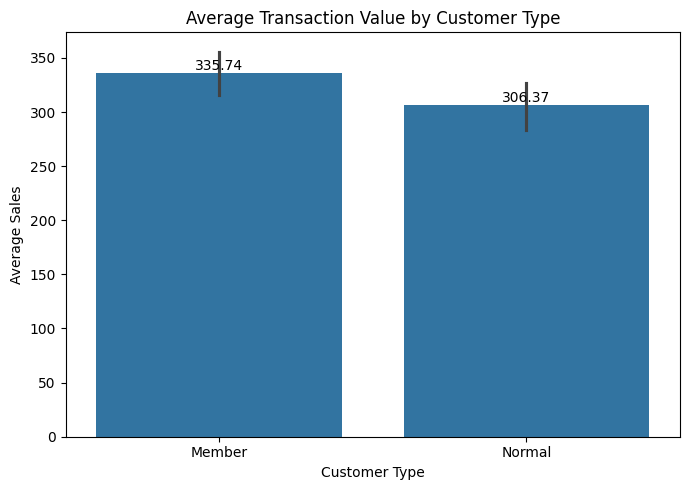

In [38]:
plt.figure(figsize=(7,5))

ax=sns.barplot(
    data=sales_data,
    x="Customer type",
    y="Sales",
    estimator="mean"
)

plt.title("Average Transaction Value by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Sales")

for container in ax.containers:
    ax.bar_label(container,fmt="%.2f")
    
plt.tight_layout()
plt.show()

### Q.7. Is there a difference in average transaction value between male and female customers?

In [39]:
# Is there a difference in spending between male and female customers ? 

sales_data.groupby("Gender")["Sales"].mean()

Gender
Female    340.931414
Male      299.055738
Name: Sales, dtype: float64

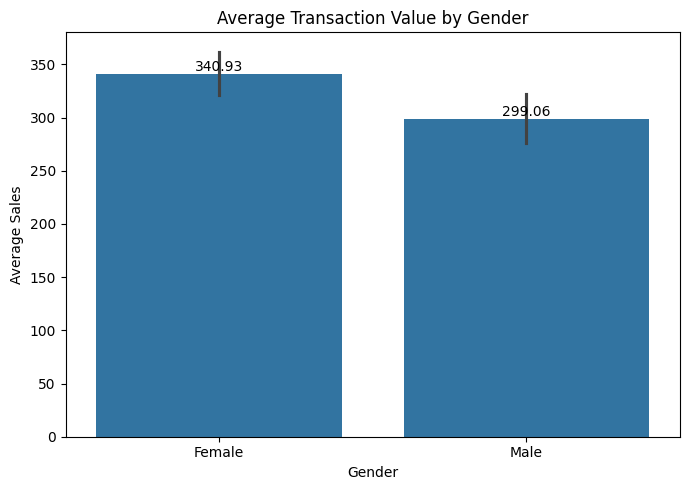

In [40]:
plt.figure(figsize=(7,5))

ax=sns.barplot(
    data=sales_data,
    x="Gender",
    y="Sales",
    estimator="mean"
)

plt.title("Average Transaction Value by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Sales")

for container in ax.containers:
    ax.bar_label(container,fmt="%.2f")
    
plt.tight_layout()
plt.show()

In [41]:
sales_data["Gender"].value_counts()

Gender
Female    571
Male      429
Name: count, dtype: int64

In [42]:
# Is the difference Statiscally Significant ? 

from scipy.stats import ttest_ind 

female=sales_data[sales_data["Gender"]=="Female"]["Sales"]
male=sales_data[sales_data["Gender"]=="Male"]["Sales"]

t,p = ttest_ind(female,male)

print(f"t-statistic = {t:.3f}")
print(f"p-value = {p:.4f}")

t-statistic = 2.674
p-value = 0.0076


### Q.8. Which payment methods are most commonly used?

In [43]:
# Which Payment Methods are most commonly used ? 

sales_data["Payment"].value_counts()

Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

In [44]:
# Percent Share (important - Ewallet vs Cash gap is only 1 Transaction)

(sales_data["Payment"].value_counts(normalize=True)*100).round(2)

Payment
Ewallet        34.5
Cash           34.4
Credit card    31.1
Name: proportion, dtype: float64

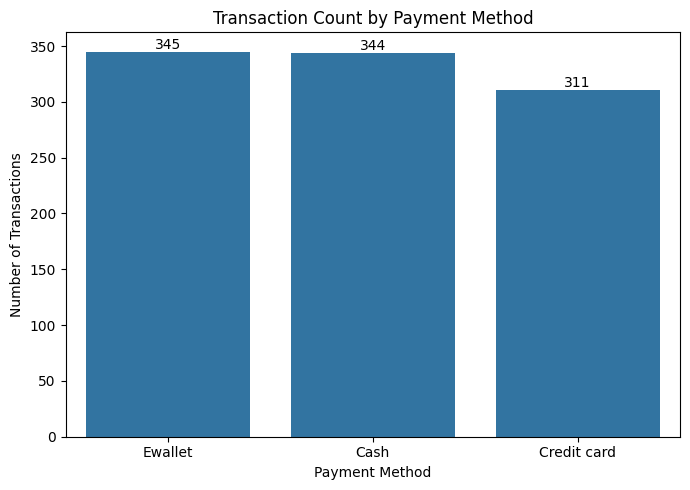

In [45]:
plt.figure(figsize=(7,5))

payment_order = sales_data["Payment"].value_counts().index

ax=sns.countplot(
    data=sales_data,
    x="Payment",
    order=payment_order
)

plt.title("Transaction Count by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container)
    
plt.tight_layout()
plt.show()

Note: Ewallet (34.5%) and Cash (34.4%) are effective tied; Credit Card lags slightly at 31.1%. The 1-transaction  gap between Ewallet and Cash is within statistical noise - they should be reported as co-leaders rather than ranked.

## Bonus: Average Transaction value by Branch

In [46]:
# What is the Average transaction value for each branch ? 

sales_data.groupby("Branch")["Sales"].mean()

Branch
Alex     312.354031
Cairo    319.872506
Giza     337.099715
Name: Sales, dtype: float64

# Summary of Findings 

## Sales 

- **Total Revenue:** 322,966.75 across 1,000 transactions (Jan 1 - Mar 30, 2019)
- **Top Branch:** Giza (110,568.71), followed closely by Alex and Cairo
- **Monthly Trend:** January (116,291.87) > March (109,455.51) > February (97,219.37)


## Products

- **Top by Revenue:** Food and Beverages (56,144.84)
- **Top by Units:** Electronic accessories (971 Units)
- **Key insight:** Different winners because Food and beverages has a higher average unit price (56.01 vs 53.55) - pricing power vs volume driven sales


## Customers 

- **By Type:** Members spend 335.74/transaction vs 306.37 for Normal Customers (~10% more)
- **By Gender:** Female customers spend 340.93/transaction vs 299.06 for Male (~14% more)
- The Gender difference was confirmed statistically significant via a two-sample t-test (t=2.674, p=0.0076). The customer type difference was observed descriptively but not statistically tested. 


## Payments 

- **Ewallet (34.5%)** and **Cash (34.4%)** are effectively tied as most used methods
- **Credit Card (31.1%)** lags slightly behind 
- The Ewallet-cash gap is 1 transaction out of 1,000 - a statistical tie


## Tools Used 

Python . Pandas . Numpy . Matplotlib . Scipy . Seaborn 